<a href="https://colab.research.google.com/github/sravananambiar20/Predictive-lab-exam/blob/main/predictive_lab_exam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df = pd.read_csv("/content/Lab_Exam_binary_classification_dataset.csv")

In [ ]:
df.head()
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Feature1  1020 non-null   float64
 1   Feature2  1020 non-null   int64  
 2   Target    1000 non-null   object 
dtypes: float64(1), int64(1), object(1)
memory usage: 24.0+ KB
None
           Feature1     Feature2
count   1020.000000  1020.000000
mean      11.436679   520.988235
std      313.061049    69.793442
min        1.250000   400.000000
25%        1.450000   464.000000
50%        1.637500   520.000000
75%        1.828125   584.000000
max    10000.000000   640.000000


In [ ]:
df.head()

,Feature1,Feature2,Target
0,1.7250,520,Yes
1,1.8875,428,No
2,1.6000,552,Yes
3,1.4250,500,No
4,1.7750,628,No


In [ ]:
df.isnull().sum()

,0
Feature1,0
Feature2,0
Target,20


In [ ]:
df.dropna(inplace=True)

In [ ]:
df.isnull().sum()

,0
Feature1,0
Feature2,0
Target,0


In [ ]:
df['Target'] = df['Target'].map({'Yes': 1, 'No': 0})

In [ ]:
df.head()

,Feature1,Feature2,Target
0,1.7250,520,1
1,1.8875,428,0
2,1.6000,552,1
3,1.4250,500,0
4,1.7750,628,0


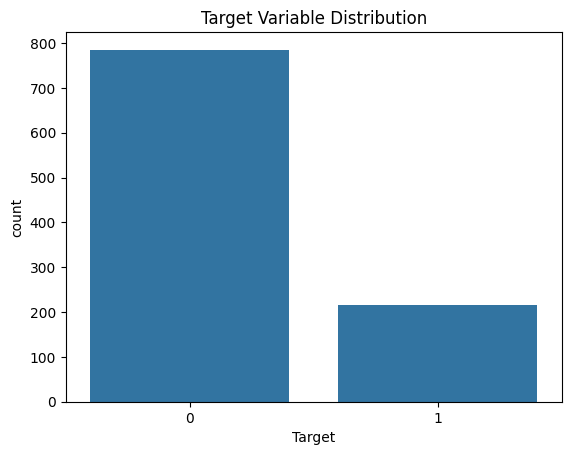

In [ ]:
plt.figure()
sns.countplot(x='Target', data=df)
plt.title("Target Variable Distribution")
plt.show()

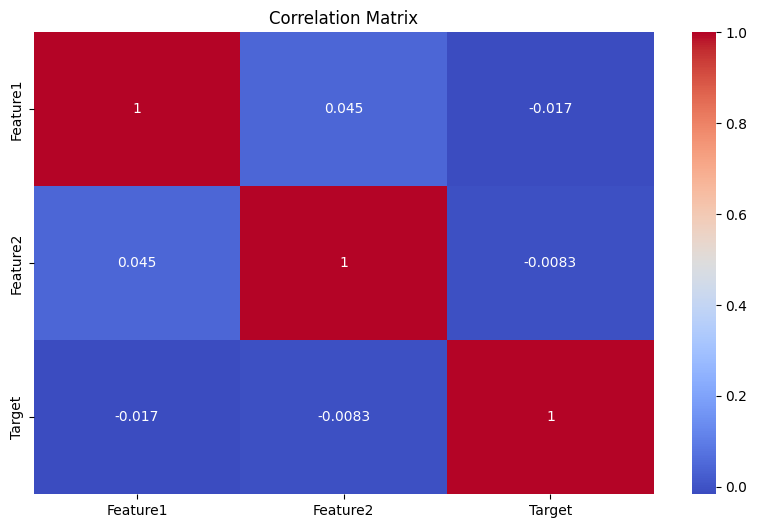

In [ ]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

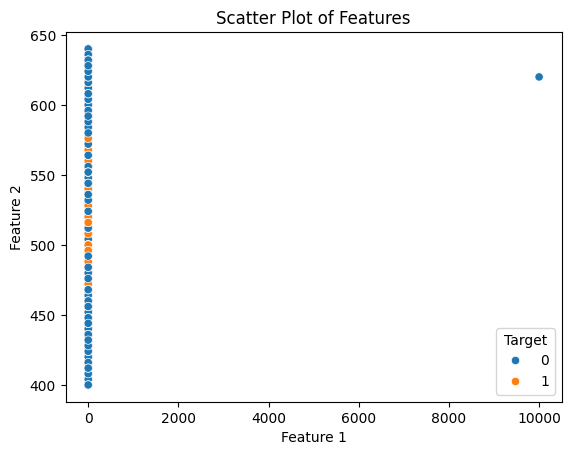

In [ ]:
target = df.columns[-1]

plt.figure()
sns.scatterplot(x=df['Feature1'], y=df['Feature2'], hue=df[target])
plt.title("Scatter Plot of Features")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

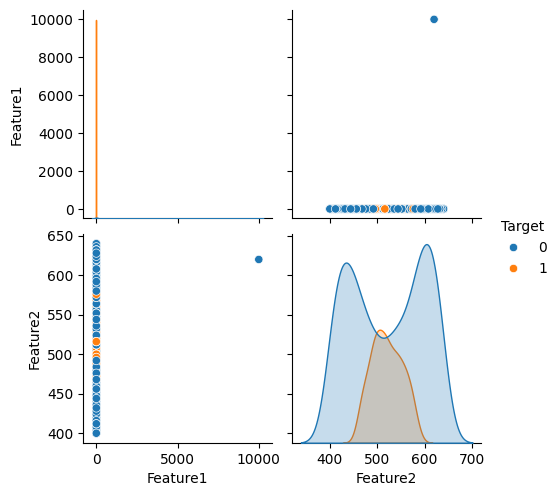

In [ ]:
sns.pairplot(df, hue=target)
plt.show()

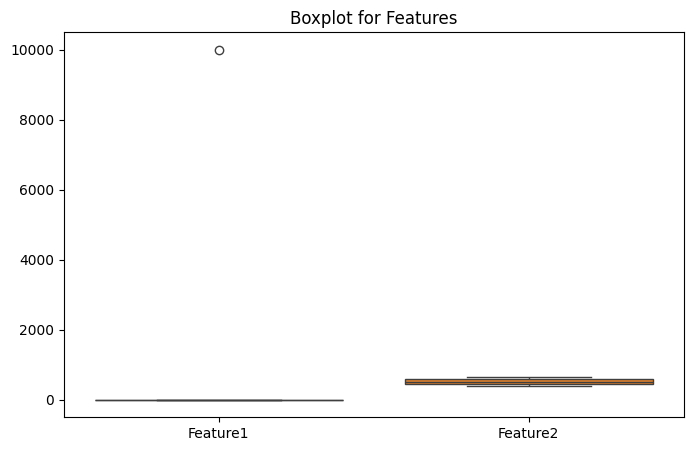

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df[['Feature1', 'Feature2']])
plt.title("Boxplot for Features")
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier



In [ ]:
X = df[['Feature1', 'Feature2']].values
y = df['Target'].values

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)


In [ ]:
model = DecisionTreeClassifier(random_state=42)

model.fit(X_train, y_train)


DecisionTreeClassifier(random_state=42)

In [ ]:
y_pred = model.predict(X_test)


In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.935

Confusion Matrix:
 [[147   6]
 [  7  40]]

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.96      0.96       153
           1       0.87      0.85      0.86        47

    accuracy                           0.94       200
   macro avg       0.91      0.91      0.91       200
weighted avg       0.93      0.94      0.93       200



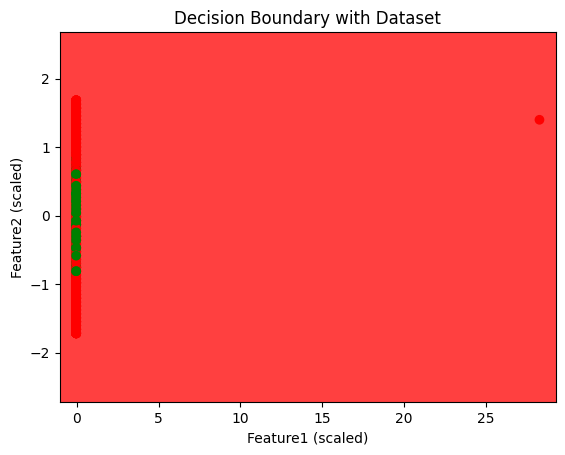

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# Use training data
X_set, y_set = X_train, y_train

# Create mesh grid
X1, X2 = np.meshgrid(
    np.arange(start=X_set[:, 0].min() - 1, stop=X_set[:, 0].max() + 1, step=0.01),
    np.arange(start=X_set[:, 1].min() - 1, stop=X_set[:, 1].max() + 1, step=0.01)
)

# Predict over grid
Z = model.predict(np.array([X1.ravel(), X2.ravel()]).T)
Z = Z.reshape(X1.shape)

# Plot decision boundary
plt.contourf(X1, X2, Z, alpha=0.75, cmap=ListedColormap(('red', 'green')))

# Plot actual data points
plt.scatter(X_set[:, 0], X_set[:, 1], c=y_set, cmap=ListedColormap(('red', 'green')))

# Labels and title
plt.title("Decision Boundary with Dataset")
plt.xlabel("Feature1 (scaled)")
plt.ylabel("Feature2 (scaled)")

plt.show()